Improve the MNIST digit recognizer by modifying the network architecture(layer,neurons, activaiton,dropout) and achieve higher accuracy while explaning you design choices.

In [ ]:
# import all required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

Load the dataset

In [ ]:
(X_train, y_train),(X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


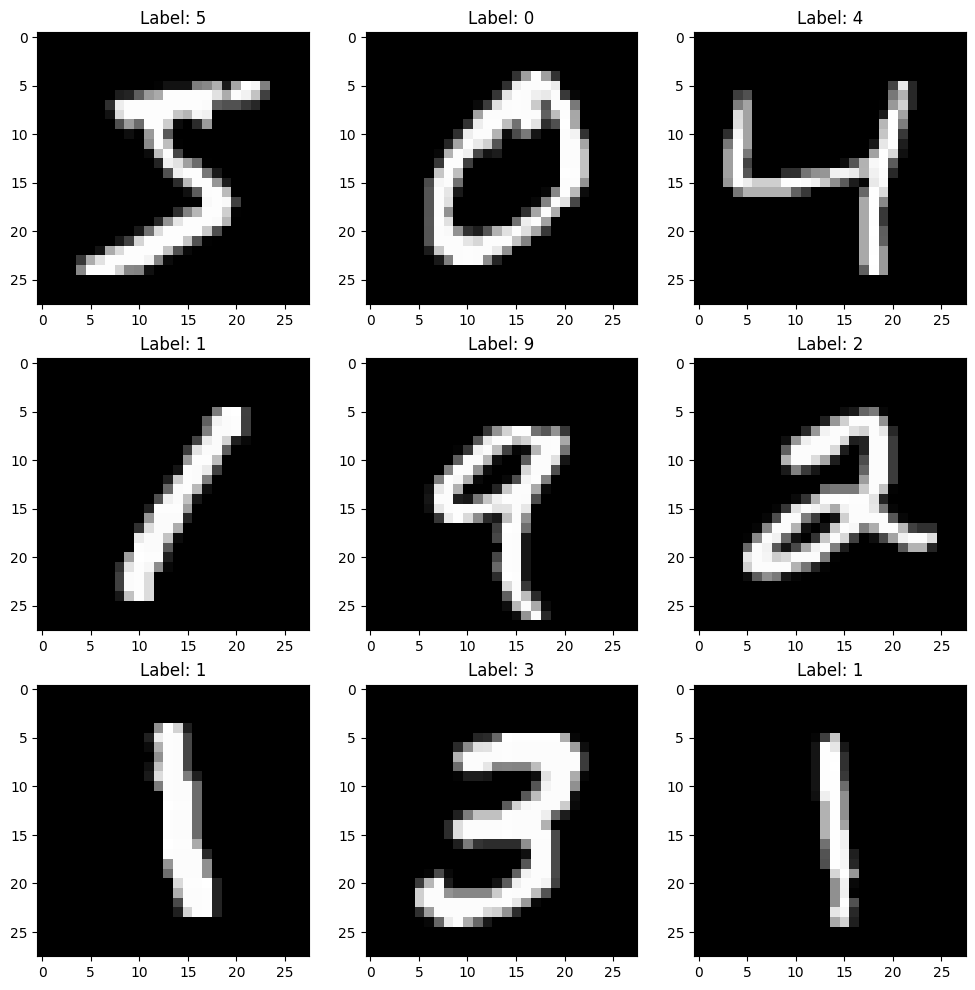

In [ ]:
import matplotlib.pyplot as plt

#function defination
def show_images(images, lables, num):
  plt.figure(figsize=(12,12))
  for i in range(num):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i],cmap = 'gray')
    plt.title(f"Label: {lables[i]}")
  plt.show()

# function calling
show_images(X_train,y_train, 9)

In [ ]:
X_train = X_train.reshape(-1,28*28).astype('float32')/255.0
X_test = X_test.reshape(-1,28*28).astype('float32')/255.0

Define the model

In [ ]:
model = models.Sequential([
    # hidden layer 1
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # hidden layer 2
    layers.Dense(64, activation='relu'),
    #hidden layer 3
    layers.Dense(32, activation = 'relu'),
    #hidden layer 4
    layers.Dense( 16, activation='relu'),
    # output layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Complile the model

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Train the model

In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size=64)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9013 - loss: 0.3269
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9626 - loss: 0.1231
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9730 - loss: 0.0867
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9787 - loss: 0.0671
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9826 - loss: 0.0552
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9860 - loss: 0.0448
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9879 - loss: 0.0382
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9899 - loss: 0.0311
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9906 - loss: 0.0290
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9920 - loss: 0.0242
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9918 - loss: 0.0247
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [ ]:
test_loss, test_acf = model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9788 - loss: 0.1139


To upload the 0-9 images file to check the prediction is correct or not

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


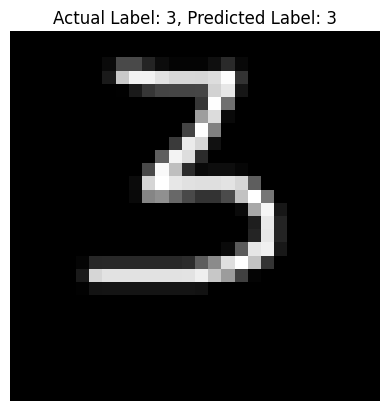

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/Mnist3.PNG' # Corrected typo from 'Mnist9.PNG' to 'Mnsit9.PNG'
img = Image.open(image_path).convert('L') # Convert to grayscale

# Resize the image to 28x28 pixels, matching MNIST input size
img = img.resize((28, 28))

# Convert image to numpy array and normalize
img_array = np.array(img)
img_array = img_array.reshape(1, 28 * 28).astype('float32') / 255.0

# Make prediction
prediction = model.predict(img_array)
predicted_label = np.argmax(prediction)

# Extract actual label from filename (assuming format 'MnistX.PNG')
actual_label = int(image_path.split('/')[-1].replace('Mnist', '').replace('.PNG', ''))

# Display the image and prediction
plt.imshow(img, cmap='gray')
plt.title(f"Actual Label: {actual_label}, Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()